## 描绘突变体拟合

In [1]:
# 预定义参数
import torch
kineticsType = "kcat"
datasetType = "test"
dataPath = f"../Data/{kineticsType.upper()}TestPairInfo"
# modelPath = "../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-8/model/pre-train-trainR2:0.9408-devR2=0.7459-RMSE=0.7751-MAE=0.4787-epoch=3"
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-1/model/pre-train-trainR2:0.9161-devR2=0.6674-RMSE=0.8867-MAE=0.5639-epoch=100",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-1/model/pre-train-trainR2:0.8980-devR2=0.6307-RMSE=0.7941-MAE=0.5537-epoch=100",
    'kkm':"../../KKM/TrainInfo/models/initialTrain-MACCSKeys/ECFPKKmPredictor-trainR2:0.8893-devR2=0.6136-RMSE=1.1116-MAE=0.7944-epoch=100"
}
# 加载数据集
rawData = torch.load("../../KCAT/Data/all_kinetics_data.pt")
dataPairInfo = torch.load(dataPath)
# 分类
wildTypePair = []
mutantTypePair = []
for item in dataPairInfo:
    if len(item[3]) < 2:
        if rawData['kinetics_data'][kineticsType][item[3][0]]['type'] == 'mutant':
            mutantTypePair.append(item)
        else:
            wildTypePair.append(item)

In [2]:
# 预测
import sys
sys.path.append("../")
from tools import getPairInfo, metric
from predictor_base import predict

mutantReal, mutantPre = predict(
                    kineticsType.upper(),
                    modelPath[kineticsType],
                    mutantTypePair,
                    f"../../{kineticsType.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{kineticsType.upper()}/Data/NewestFeature/index_smiles",
                    True if kineticsType != 'kkm' else False,
                    torch.device("cuda:0"),
                    "MACCSKeys"
                   )
wildReal, wildPre = predict(
                    kineticsType.upper(),
                    modelPath[kineticsType],
                    wildTypePair,
                    f"../../{kineticsType.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{kineticsType.upper()}/Data/NewestFeature/index_smiles",
                    True if kineticsType != 'kkm' else False,
                    torch.device("cuda:0"),
                    "MACCSKeys"
                   )

log10:True molType:MACCSKeys
F


100%|█████████████████████████████████████████████████████████████| 15/15 [00:10<00:00,  1.49it/s]


log10:True molType:MACCSKeys
F


100%|█████████████████████████████████████████████████████████████| 21/21 [00:11<00:00,  1.90it/s]


In [5]:
pre = mutantPre
real = mutantReal

{'MAE': 0.45567556474946597, 'rmse': 0.7453397727961957, 'r2': 0.7657127473769534, 'r': 0.8763084822549334, 'p_value': 0.0, 'samples': 1412}


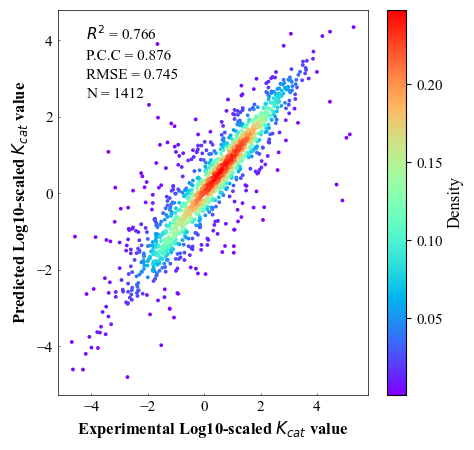

In [20]:
Result = metric(pre, real, True if kineticsType != 'kkm' else False)
print(Result)
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
plt.figure(figsize=(5,5))
rc('font',**{'family':'Times New Roman'})
plt.rcParams['pdf.fonttype'] = 42

plt.tick_params(direction='in')
plt.tick_params(which='major',length=1.5)
plt.tick_params(which='major',width=0.4)
vstack = np.vstack([real,pre])
experimental_predicted = gaussian_kde(vstack)(vstack)
ax = plt.scatter(x = real, y = pre, c=experimental_predicted, s=3, cmap='rainbow')
cbar = plt.colorbar(ax)
cbar.ax.tick_params(labelsize=11)
cbar.set_label('Density', size=12)

plt.text(-4.2, 4.0, '$R^{2}$ = %.3f' % Result['r2'], fontweight ="normal", fontsize=11)
plt.text(-4.2, 3.5, 'P.C.C = %.3f' % Result['r'], fontweight ="normal", fontsize=11)
plt.text(-4.2, 3.0, 'RMSE = %.3f' % Result['rmse'], fontweight ="normal", fontsize=11)
plt.text(-4.2, 2.5, f'N = {len(mutantTypePair)}', fontweight ="normal", fontsize=11)

plt.xlabel("Experimental Log10-scaled $K_{cat}$ value", fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12})
plt.ylabel('Predicted Log10-scaled $K_{cat}$ value',fontdict={'weight': 'bold', 'fontname': 'Times New Roman', 'size': 12})

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# plt.ylim(-4)
# plt.xlim(-7)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)

plt.savefig(f"../Fig/Fig3-MACCSKeys-{kineticsType}-mutant-TestDataset.png", dpi=600, bbox_inches='tight')
plt.show()